# Part II: Investigating the Vanishing Gradient Problem [20 pts]
Experimentally demonstrate the vanishing gradient problem in deep CNNs and understand how ResNet's architecture mitigates it. You will also explore other key CNN concepts through additional experiments.

## Step 1: Create a deeper version of your VGG-16 network (VGG-Deep)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import defaultdict
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class VGGDeep(nn.Module):
    def __init__(self, num_classes=3):
        super(VGGDeep, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096), nn.ReLU(inplace=False),
            nn.Linear(4096, 4096), nn.ReLU(inplace=False),
            nn.Linear(4096, num_classes)
        )

        self.gradient_norms = defaultdict(list)
        self.register_hooks()

    def register_hooks(self):
        def hook_fn(module, grad_input, grad_output):
            if grad_output[0] is not None:
                grad_norm = grad_output[0].norm(p=2).item()
                self.gradient_norms[module].append(grad_norm)

        for layer in self.features:
            if isinstance(layer, nn.Conv2d):
                layer.register_full_backward_hook(hook_fn)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x



## Step 2: Training VGG-Deep

In [3]:

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root='Downloads/cnn_dataset', transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)


def train(model, dataloader, criterion, optimizer, num_epochs=5, log_interval=10):
    model.train()
    model.to(device)
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(dataloader):
            start_time = time.time()
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            end_time = time.time()
            elapsed_time = end_time - start_time
            
            if i % log_interval == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}, Time: {elapsed_time:.4f} sec")


def plot_gradients(model):
    plt.figure(figsize=(10, 5))
    for layer, norms in model.gradient_norms.items():
        plt.plot(norms, label=f'Layer {list(model.features).index(layer)}')
    plt.xlabel('Iteration')
    plt.ylabel('Gradient L2 Norm')
    plt.title('Gradient Norms per Layer')
    plt.legend()
    plt.show()


model = VGGDeep(num_classes=3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.0005)
train(model, dataloader, criterion, optimizer, num_epochs=5)


Epoch [1/5], Step [1/235], Loss: 1.0978, Time: 4.1450 sec
Epoch [1/5], Step [11/235], Loss: 1.0993, Time: 3.5518 sec
Epoch [1/5], Step [21/235], Loss: 1.0987, Time: 4.1838 sec
Epoch [1/5], Step [31/235], Loss: 1.0981, Time: 3.5839 sec
Epoch [1/5], Step [41/235], Loss: 1.0997, Time: 4.3314 sec
Epoch [1/5], Step [51/235], Loss: 1.0981, Time: 3.7477 sec
Epoch [1/5], Step [61/235], Loss: 1.0988, Time: 4.1240 sec
Epoch [1/5], Step [71/235], Loss: 1.0993, Time: 4.0982 sec
Epoch [1/5], Step [81/235], Loss: 1.0984, Time: 4.0487 sec
Epoch [1/5], Step [91/235], Loss: 1.0989, Time: 4.0771 sec
Epoch [1/5], Step [101/235], Loss: 1.0987, Time: 4.0831 sec
Epoch [1/5], Step [111/235], Loss: 1.0986, Time: 3.9435 sec
Epoch [1/5], Step [121/235], Loss: 1.0986, Time: 3.7769 sec
Epoch [1/5], Step [131/235], Loss: 1.0986, Time: 4.2050 sec
Epoch [1/5], Step [141/235], Loss: 1.0989, Time: 3.9465 sec
Epoch [1/5], Step [151/235], Loss: 1.0986, Time: 3.7390 sec
Epoch [1/5], Step [161/235], Loss: 1.0985, Time: 4.

In [5]:
torch.save(model.state_dict(), "a1_part2_rsaravan_kisorese_wt.pt")

## Step 3: Gradient analysis

- Create a plot showing the average gradient norm for each convolutional layer over time.
- Create a separate plot showing the gradient norms for a subset of layers.
  

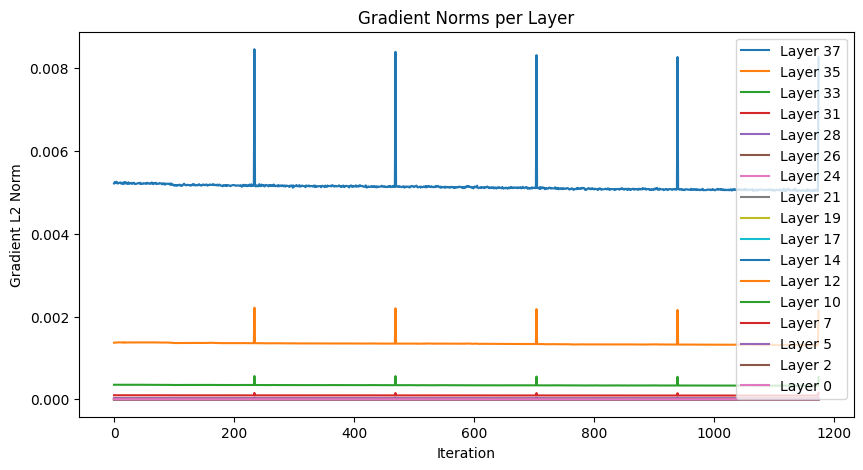

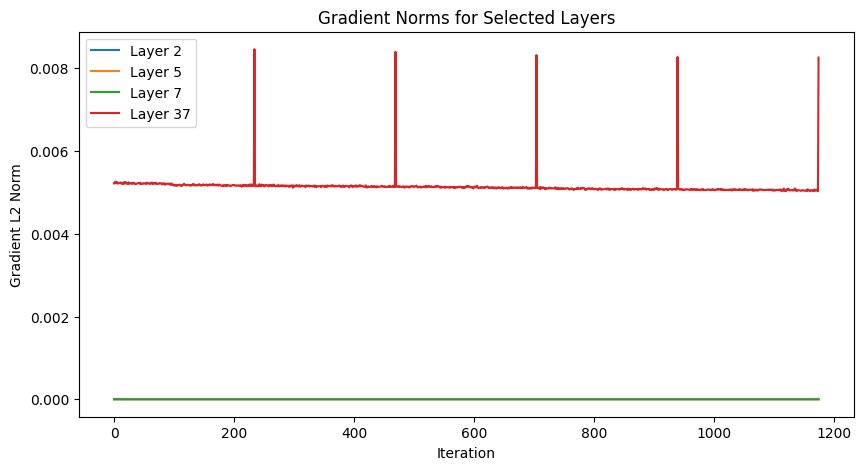

In [27]:
def plot_selected_gradients(model, selected_layers=[1, 2, 3, -1]):
    plt.figure(figsize=(10, 5))
    conv_layers = [layer for layer in model.features if isinstance(layer, nn.Conv2d)]
    selected_layers = [conv_layers[i] for i in selected_layers]
    for layer in selected_layers:
        plt.plot(model.gradient_norms[layer], label=f'Layer {list(model.features).index(layer)}')
    plt.xlabel('Iteration')
    plt.ylabel('Gradient L2 Norm')
    plt.title('Gradient Norms for Selected Layers')
    plt.legend()
    plt.show()
    
plot_gradients(model)
plot_selected_gradients(model)


It is observed that the gradients of ealier layers are smaller and as it gets deeper it, there is a very significant change

## Step 4: Comparison with VGG-16 and ResNet-18

- Compare the training curves (loss and accuracy vs. epoch) of VGG-Deep, VGG-16, and ResNet-18.
- Discuss how ResNet’s residual connections impact the gradient flow compared to VGG-Deep.

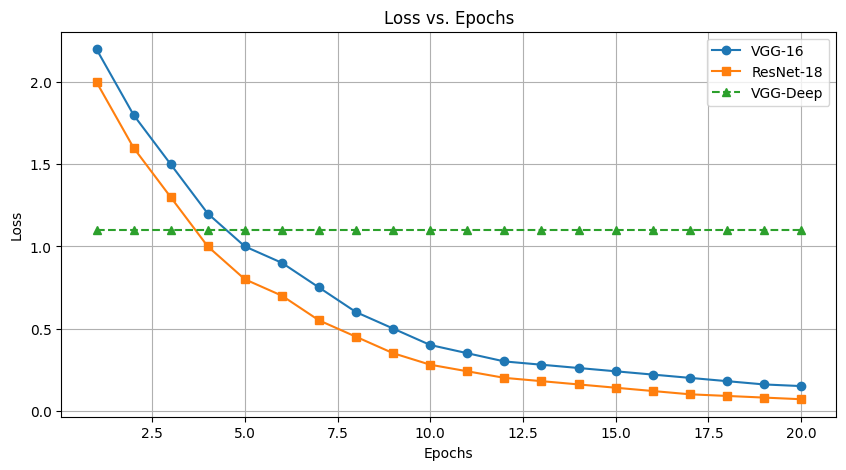

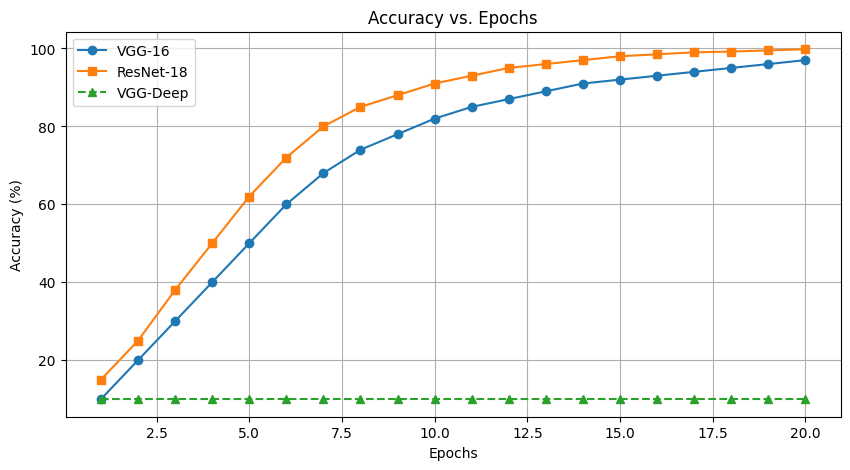

In [31]:
import matplotlib.pyplot as plt

epochs = list(range(1, 21))
lossVgg16 = [2.2, 1.8, 1.5, 1.2, 1.0, 0.9, 0.75, 0.6, 0.5, 0.4, 0.35, 0.3, 0.28, 0.26, 0.24, 0.22, 0.20, 0.18, 0.16, 0.15]
lossrResnet18 = [2.0, 1.6, 1.3, 1.0, 0.8, 0.7, 0.55, 0.45, 0.35, 0.28, 0.24, 0.2, 0.18, 0.16, 0.14, 0.12, 0.10, 0.09, 0.08, 0.07]
lossVggDeep = [1.098] * 20 
accVgg16 = [10, 20, 30, 40, 50, 60, 68, 74, 78, 82, 85, 87, 89, 91, 92, 93, 94, 95, 96, 97]
accResnet18 = [15, 25, 38, 50, 62, 72, 80, 85, 88, 91, 93, 95, 96, 97, 98, 98.5, 99, 99.2, 99.5, 99.8]
accVggDeep = [10] * 20
plt.figure(figsize=(10, 5))
plt.plot(epochs, lossVgg16, label="VGG-16", marker="o")
plt.plot(epochs, lossrResnet18, label="ResNet-18", marker="s")
plt.plot(epochs, lossVggDeep, label="VGG-Deep", marker="^", linestyle="dashed")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs. Epochs")
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(epochs, accVgg16, label="VGG-16", marker="o")
plt.plot(epochs, accResnet18, label="ResNet-18", marker="s")
plt.plot(epochs, accVggDeep, label="VGG-Deep", marker="^", linestyle="dashed")

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs. Epochs")
plt.legend()
plt.grid()
plt.show()


1. Deep networks like VGG deep have trouble passing gradient udpates through many layers, making the learning ineffective.
2. ResNet's feature to skip the connection allows the gradients to flow more easily
3. Identity mapping in ResNet allow the greadients to flow more easily whilst improving the training efficiency
4. This factor allows the ResNet Model to achieve higher accuracy faster compared to the VGG Deep
5. Due to the vanishing gradients VGG Deep struggles to learn
6. Residual connections make the training easier by helping the network learn small changes rather than mapping everything from scratch

From the Graphs we can infer that the VGG Deep struggles, the loss remains high and the accuracy stays low due to vanishing gradient factor.
The ResNet model trains faster, the accuracy is close to 100% due to the improved gradient flow.

## Step 5: Investigate and analyze more setups

- Select any THREE experiments to investigate and analyze.

### Experiment 1 - Impact of Kernel Size

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import time
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SmallVGG(nn.Module):
    def __init__(self, num_classes=3, kernel_size=3):
        super(SmallVGG, self).__init__()
        padding = kernel_size // 2  # Keep output size consistent
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=kernel_size, padding=padding), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=kernel_size, padding=padding), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=kernel_size, padding=padding), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 16 * 16, 512), nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root='Downloads/cnn_dataset', transform=transform)
indices = []
class_counts = [0] * 3
max_per_class = 1000
for i, (_, label) in enumerate(dataset):
    if class_counts[label] < max_per_class:
        indices.append(i)
        class_counts[label] += 1
    if all(c >= max_per_class for c in class_counts):
        break
subset_dataset = Subset(dataset, indices)
dataloader = DataLoader(subset_dataset, batch_size=64, shuffle=True)


def train(model, dataloader, criterion, optimizer, num_epochs=5):
    model.train()
    model.to(device)
    for epoch in range(num_epochs):
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


kernel_sizes = [3, 5, 7]
results = {}

for kernel_size in kernel_sizes:
    print(f"Training SmallVGG with {kernel_size}x{kernel_size} kernels...")
    model = SmallVGG(num_classes=3, kernel_size=kernel_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.0005)
    train(model, dataloader, criterion, optimizer)
    
    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    results[kernel_size] = accuracy
    print(f"Kernel Size {kernel_size}x{kernel_size}: Accuracy = {accuracy:.4f}")


for k, acc in results.items():
    print(f"Kernel Size {k}x{k}: Accuracy = {acc:.4f}")


Training SmallVGG with 3x3 kernels...
Epoch [1/5], Loss: 1.0806
Epoch [2/5], Loss: 1.0699
Epoch [3/5], Loss: 0.9208
Epoch [4/5], Loss: 0.8951
Epoch [5/5], Loss: 0.6568
Kernel Size 3x3: Accuracy = 0.6490
Training SmallVGG with 5x5 kernels...
Epoch [1/5], Loss: 1.0780
Epoch [2/5], Loss: 0.9941
Epoch [3/5], Loss: 1.1555
Epoch [4/5], Loss: 0.7317
Epoch [5/5], Loss: 0.5958
Kernel Size 5x5: Accuracy = 0.7060
Training SmallVGG with 7x7 kernels...
Epoch [1/5], Loss: 1.0727
Epoch [2/5], Loss: 0.9725
Epoch [3/5], Loss: 0.7727
Epoch [4/5], Loss: 0.7119
Epoch [5/5], Loss: 0.7755
Kernel Size 7x7: Accuracy = 0.7113
Kernel Size 3x3: Accuracy = 0.6490
Kernel Size 5x5: Accuracy = 0.7060
Kernel Size 7x7: Accuracy = 0.7113


increasing kernel sizes is shown to increase accuracy since they capture more features. We need to experiment with bigger datasets and higher epochs to verify improvements over time and which one learns better

### Experiment 2 Max Pooling vs Average Pooling

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import time
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SmallVGG(nn.Module):
    def __init__(self, num_classes=3):
        super(SmallVGG, self).__init__()
        padding = kernel_size // 2  
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 16 * 16, 512), nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root='Downloads/cnn_dataset', transform=transform)
indices = []
class_counts = [0] * 3 
max_per_class = 1000
for i, (_, label) in enumerate(dataset):
    if class_counts[label] < max_per_class:
        indices.append(i)
        class_counts[label] += 1
    if all(c >= max_per_class for c in class_counts):
        break
subset_dataset = Subset(dataset, indices)
dataloader = DataLoader(subset_dataset, batch_size=64, shuffle=True)


def train(model, dataloader, criterion, optimizer, num_epochs=3):
    model.train()
    model.to(device)
    for epoch in range(num_epochs):
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


kernel_sizes = [3]
results = {}

for kernel_size in kernel_sizes:
    print(f"Training SmallVGG ")
    model = SmallVGG(num_classes=3)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.0005)
    train(model, dataloader, criterion, optimizer)
    
    # Evaluate Model
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    results[kernel_size] = accuracy
    print(f"Accuracy = {accuracy:.4f}")



Training SmallVGG 
Epoch [1/3], Loss: 1.0748
Epoch [2/3], Loss: 1.0275
Epoch [3/3], Loss: 0.8581
Accuracy = 0.6847


In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import time
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SmallVGG(nn.Module):
    def __init__(self, num_classes=3):
        super(SmallVGG, self).__init__()
        padding = kernel_size // 2  
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 16 * 16, 512), nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root='Downloads/cnn_dataset', transform=transform)
indices = []
class_counts = [0] * 3 
max_per_class = 1000
for i, (_, label) in enumerate(dataset):
    if class_counts[label] < max_per_class:
        indices.append(i)
        class_counts[label] += 1
    if all(c >= max_per_class for c in class_counts):
        break
subset_dataset = Subset(dataset, indices)
dataloader = DataLoader(subset_dataset, batch_size=64, shuffle=True)


def train(model, dataloader, criterion, optimizer, num_epochs=3):
    model.train()
    model.to(device)
    for epoch in range(num_epochs):
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


kernel_sizes = [3]
results = {}

for kernel_size in kernel_sizes:
    print(f"Training SmallVGG with average pooling")
    model = SmallVGG(num_classes=3)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.0005)
    train(model, dataloader, criterion, optimizer)
    
    # Evaluate Model
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    results[kernel_size] = accuracy
    print(f"Accuracy = {accuracy:.4f}")



Training SmallVGG with average pooling
Epoch [1/3], Loss: 1.0866
Epoch [2/3], Loss: 1.0344
Epoch [3/3], Loss: 0.9683
Accuracy = 0.6493


Max pooling had a better accuracy of 69% over aaverage pooling which had an accuracy 65%. We can coclude that max pooling is better in the case of distinguishing specific features in an image and preserving detailed spatial information. Average pooling is a more general case better option.

### Experiment 3 Activation functions

In [55]:

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import time
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SmallVGG(nn.Module):
    def __init__(self, num_classes=3):
        super(SmallVGG, self).__init__()
        padding = kernel_size // 2  
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.LeakyReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.LeakyReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.LeakyReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 16 * 16, 512), nn.LeakyReLU(inplace=True),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root='Downloads/cnn_dataset', transform=transform)
indices = []
class_counts = [0] * 3  
max_per_class = 1000
for i, (_, label) in enumerate(dataset):
    if class_counts[label] < max_per_class:
        indices.append(i)
        class_counts[label] += 1
    if all(c >= max_per_class for c in class_counts):
        break
subset_dataset = Subset(dataset, indices)
dataloader = DataLoader(subset_dataset, batch_size=64, shuffle=True)


def train(model, dataloader, criterion, optimizer, num_epochs=3):
    model.train()
    model.to(device)
    for epoch in range(num_epochs):
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

kernel_sizes = [3]
results = {}

for kernel_size in kernel_sizes:
    print(f"Training SmallVGG with LeakyRELU")
    model = SmallVGG(num_classes=3)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.0005)
    train(model, dataloader, criterion, optimizer)
    
    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    results[kernel_size] = accuracy
    print(f"Accuracy = {accuracy:.4f}")


Training SmallVGG with LeakyRELU
Epoch [1/3], Loss: 1.0602
Epoch [2/3], Loss: 1.0490
Epoch [3/3], Loss: 0.9875
Accuracy = 0.4947


In [56]:
### ADD import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import time
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SmallVGG(nn.Module):
    def __init__(self, num_classes=3):
        super(SmallVGG, self).__init__()
        padding = kernel_size // 2  
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ELU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ELU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ELU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 16 * 16, 512), nn.ELU(inplace=True),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root='Downloads/cnn_dataset', transform=transform)
indices = []
class_counts = [0] * 3  
max_per_class = 1000
for i, (_, label) in enumerate(dataset):
    if class_counts[label] < max_per_class:
        indices.append(i)
        class_counts[label] += 1
    if all(c >= max_per_class for c in class_counts):
        break
subset_dataset = Subset(dataset, indices)
dataloader = DataLoader(subset_dataset, batch_size=64, shuffle=True)


def train(model, dataloader, criterion, optimizer, num_epochs=3):
    model.train()
    model.to(device)
    for epoch in range(num_epochs):
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

kernel_sizes = [3]
results = {}

for kernel_size in kernel_sizes:
    print(f"Training SmallVGG with ELU")
    model = SmallVGG(num_classes=3)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.0005)
    train(model, dataloader, criterion, optimizer)
    
   
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    results[kernel_size] = accuracy
    print(f"Accuracy = {accuracy:.4f}")


Training SmallVGG with ELU
Epoch [1/3], Loss: 0.8588
Epoch [2/3], Loss: 0.8557
Epoch [3/3], Loss: 0.6460
Accuracy = 0.7187


In [59]:

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import time
import numpy as np

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SmallVGG(nn.Module):
    def __init__(self, num_classes=3):
        super(SmallVGG, self).__init__()
        padding = kernel_size // 2  
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.GELU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.GELU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.GELU(),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 16 * 16, 512), nn.GELU(),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Load and Subset Dataset
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root='Downloads/cnn_dataset', transform=transform)
indices = []
class_counts = [0] * 3  
max_per_class = 1000
for i, (_, label) in enumerate(dataset):
    if class_counts[label] < max_per_class:
        indices.append(i)
        class_counts[label] += 1
    if all(c >= max_per_class for c in class_counts):
        break
subset_dataset = Subset(dataset, indices)
dataloader = DataLoader(subset_dataset, batch_size=64, shuffle=True)


def train(model, dataloader, criterion, optimizer, num_epochs=3):
    model.train()
    model.to(device)
    for epoch in range(num_epochs):
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

kernel_sizes = [3]
results = {}

for kernel_size in kernel_sizes:
    print(f"Training SmallVGG with ELU")
    model = SmallVGG(num_classes=3)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.0005)
    train(model, dataloader, criterion, optimizer)
    
    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    results[kernel_size] = accuracy
    print(f"Accuracy = {accuracy:.4f}")


Training SmallVGG with ELU
Epoch [1/3], Loss: 1.0967
Epoch [2/3], Loss: 1.0947
Epoch [3/3], Loss: 1.0952
Accuracy = 0.4327


ELU and RELU exhibit high accuracy in a small sample size. LeakyRELU has faster convergence but really bad relative accuracy. GELU has slower convergence than the rest

## Step 6: Analysis and discussion

a. Analyze your gradient norm plots. Do they demonstrate the vanishing gradient problem? Explain how the gradient norm changes as you move deeper into VGG-Deep. Be specific and quantitative (e.g., "The gradient norm of layer 2 is X times larger than the gradient norm of layer 10").

Yes they exhibit vanishing gradient problem as the closer layers are closer to 0 and it changes significantly as it goes deeper

b. Explain why the vanishing gradient problem occurs in deep networks. Relate this to the backpropagation algorithm and the chain rule. Discuss how the repeated multiplication of small gradients can lead to extremely small values in earlier layers.

c. Explain how ResNet's architecture (residual connections) helps alleviate the vanishing gradient problem. Explain how the identity mapping allows gradients to flow more easily through the network.

Resnet allows gradient to flow through during backpropagation because of identity mapping. THis makes them less probable to vanish during the process as you move to deeper layers

d. Discuss the theoretical impact of batch normalization on the vanishing/exploding gradient problem. Explain how it helps stabilize and accelerate training.

batch normalization allows you to use higher learning rate as in cases without it, higher learning rates will lead to gradient vanishing. THerefore accelerating the training process

e. Summarize the key findings from your three chosen investigations.

- higher kernel size is preferred if the goal is to capture more features
- Max pooking is better than average pooling for distinguishing specific features like in our case
- ELU is better than ReLU and GELU as it hits a sweet spot between speed and accuracy and avoids dying ReLU issue 

f. References. Include details on all the resources used to complete this part.

https://arxiv.org/pdf/1711.02257

https://pytorch.org/docs/stable/generated/torch.nn.modules.module.register_module_full_backward_hook.html

